SaaS Revenue Intelligence
Data Preparation and Exploratory Data Analysis

Business Objective:
Understand customer, subscription, invoice and payment data before performing revenue and churn analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
CUSTOMERS = pd.read_csv("../01_Data/customers.csv")
INVOICES = pd.read_csv("../01_Data/invoices.csv")
PAYMENTS = pd.read_csv("../01_Data/payments.csv")
SUBSCRIPTIONS = pd.read_csv("../01_Data/subscriptions.csv")
SUBSCRIPTION_PLANS = pd.read_csv("../01_Data/subscription_plans.csv")
PLAN_CHANGES = pd.read_csv("../01_Data/PLAN_CHANGES.csv")
CHURN_EVENTS = pd.read_csv("../01_Data/Churn_events.csv")

In [3]:
print("CUSTOMERS :", CUSTOMERS.shape)
print("INVOICES :", INVOICES.shape)
print("PAYMENTS :", PAYMENTS.shape)
print("SUBSCRIPTIONS :", SUBSCRIPTIONS.shape)
print("SUBSCRIPTION_PLANS :", SUBSCRIPTION_PLANS.shape)
print("PLAN_CHANGES :", PLAN_CHANGES.shape)
print("CHURN_EVENTS :", CHURN_EVENTS.shape)

CUSTOMERS : (25000, 6)
INVOICES : (68411, 6)
PAYMENTS : (68411, 5)
SUBSCRIPTIONS : (25000, 6)
SUBSCRIPTION_PLANS : (7, 4)
PLAN_CHANGES : (787, 5)
CHURN_EVENTS : (9757, 4)


In [4]:
TABLES = {
    "CUSTOMERS": CUSTOMERS,
    "INVOICES": INVOICES,
    "PAYMENTS": PAYMENTS,
    "SUBSCRIPTIONS": SUBSCRIPTIONS,
    "SUBSCRIPTION_PLANS": SUBSCRIPTION_PLANS,
    "PLAN_CHANGES": PLAN_CHANGES,
    "CHURN_EVENTS": CHURN_EVENTS
}

for NAME, DF in TABLES.items():

    print("\n", NAME)

    print("MISSING VALUES")

    print(DF.isnull().sum().sum())

    print("DUPLICATES")

    print(DF.duplicated().sum())


 CUSTOMERS
MISSING VALUES
0
DUPLICATES
0

 INVOICES
MISSING VALUES
0
DUPLICATES
0

 PAYMENTS
MISSING VALUES
0
DUPLICATES
0

 SUBSCRIPTIONS
MISSING VALUES
15243
DUPLICATES
0

 SUBSCRIPTION_PLANS
MISSING VALUES
0
DUPLICATES
0

 PLAN_CHANGES
MISSING VALUES
0
DUPLICATES
0

 CHURN_EVENTS
MISSING VALUES
0
DUPLICATES
0


In [5]:
for NAME, DF in TABLES.items():

    print("\n")

    print("="*50)

    print(NAME)

    print("="*50)

    print(DF.dtypes)



CUSTOMERS
customer_id            int64
signup_date              str
company_size             str
industry                 str
acquisition_channel      str
country                  str
dtype: object


INVOICES
invoice_id      int64
customer_id     int64
invoice_date      str
due_date          str
amount          int64
status            str
dtype: object


PAYMENTS
payment_id      int64
invoice_id      int64
payment_date      str
amount          int64
status            str
dtype: object


SUBSCRIPTIONS
subscription_id    int64
customer_id        int64
start_date           str
end_date             str
status               str
plan_id            int64
dtype: object


SUBSCRIPTION_PLANS
plan_id          int64
plan_name          str
billing_cycle      str
price            int64
dtype: object


PLAN_CHANGES
change_id      int64
customer_id    int64
old_plan_id    int64
new_plan_id    int64
change_date      str
dtype: object


CHURN_EVENTS
churn_event_id    int64
customer_id       int64
chur

In [6]:
for NAME, DF in TABLES.items():

    print("\n")

    print(NAME)

    print(DF.columns.tolist())



CUSTOMERS
['customer_id', 'signup_date', 'company_size', 'industry', 'acquisition_channel', 'country']


INVOICES
['invoice_id', 'customer_id', 'invoice_date', 'due_date', 'amount', 'status']


PAYMENTS
['payment_id', 'invoice_id', 'payment_date', 'amount', 'status']


SUBSCRIPTIONS
['subscription_id', 'customer_id', 'start_date', 'end_date', 'status', 'plan_id']


SUBSCRIPTION_PLANS
['plan_id', 'plan_name', 'billing_cycle', 'price']


PLAN_CHANGES
['change_id', 'customer_id', 'old_plan_id', 'new_plan_id', 'change_date']


CHURN_EVENTS
['churn_event_id', 'customer_id', 'churn_date', 'churn_reason']


In [7]:
INVOICES.describe()

,invoice_id,customer_id,amount
count,68411.00000,68411.000000,68411.000000
mean,34206.00000,8770.196270,50.608659
std,19748.69897,6600.368613,86.028444
min,1.00000,1.000000,19.000000
25%,17103.50000,3351.000000,19.000000
50%,34206.00000,7483.000000,19.000000
75%,51308.50000,12420.000000,49.000000
max,68411.00000,24999.000000,990.000000


In [8]:
print("TOTAL PAID INVOICES:",
      INVOICES[
          INVOICES["status"]=="paid"
      ].shape[0])

print("TOTAL REVENUE:",
      round(
          INVOICES[
              INVOICES["status"]=="paid"
          ]["amount"].sum(),
          2
      ))

TOTAL PAID INVOICES: 68411
TOTAL REVENUE: 3462189


In [9]:
print("COUNTRY DISTRIBUTION")

print(CUSTOMERS["country"].value_counts())

print("\n")

print("INDUSTRY DISTRIBUTION")

print(CUSTOMERS["industry"].value_counts())

print("\n")

print("COMPANY SIZE DISTRIBUTION")

print(CUSTOMERS["company_size"].value_counts())

COUNTRY DISTRIBUTION
country
Germany    6334
US         6278
India      6224
UK         6164
Name: count, dtype: int64


INDUSTRY DISTRIBUTION
industry
tech       6352
retail     6265
finance    6214
health     6169
Name: count, dtype: int64


COMPANY SIZE DISTRIBUTION
company_size
small     8444
medium    8348
large     8208
Name: count, dtype: int64


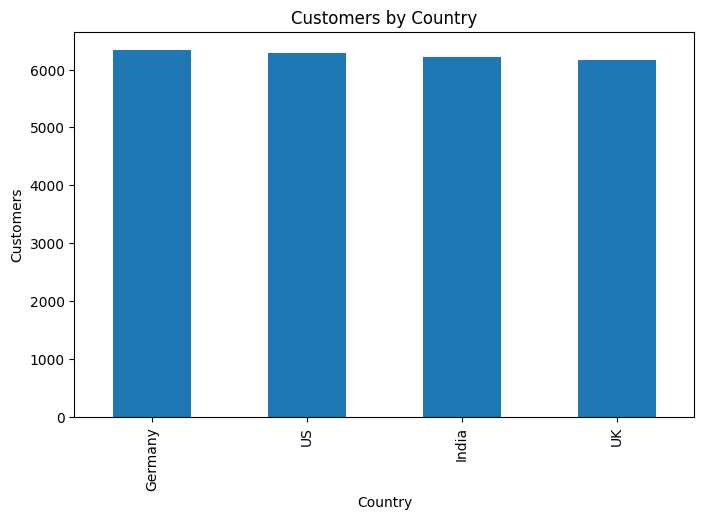

In [10]:
CUSTOMERS["country"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customers by Country")

plt.xlabel("Country")

plt.ylabel("Customers")

plt.show()

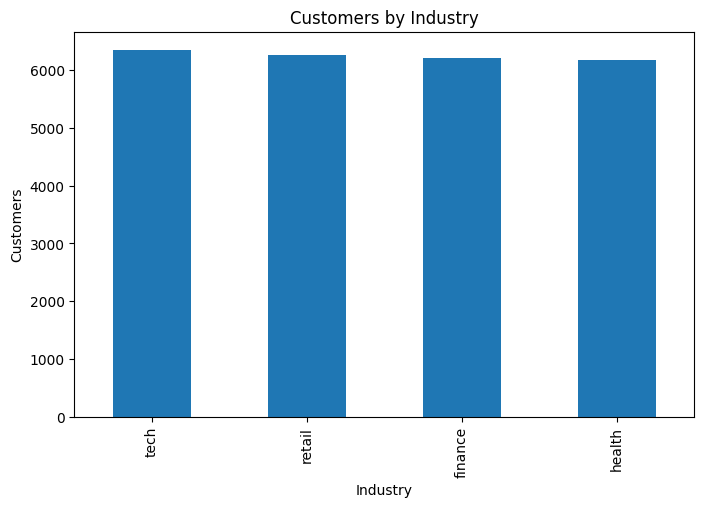

In [11]:
CUSTOMERS["industry"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customers by Industry")

plt.xlabel("Industry")

plt.ylabel("Customers")

plt.show()

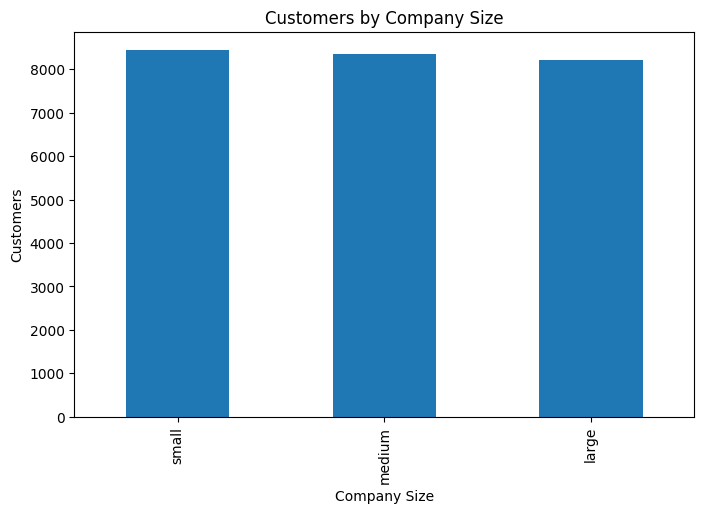

In [12]:
CUSTOMERS["company_size"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customers by Company Size")

plt.xlabel("Company Size")

plt.ylabel("Customers")

plt.show()

In [13]:
TOTAL_REVENUE = INVOICES[
    INVOICES["status"]=="paid"
]["amount"].sum()

AVERAGE_INVOICE = INVOICES["amount"].mean()

print("TOTAL REVENUE :", round(TOTAL_REVENUE,2))

print("AVERAGE INVOICE :", round(AVERAGE_INVOICE,2))

TOTAL REVENUE : 3462189
AVERAGE INVOICE : 50.61


In [20]:
CUSTOMERS["acquisition_channel"].value_counts()

acquisition_channel
organic     8418
ads         8341
referral    8241
Name: count, dtype: int64

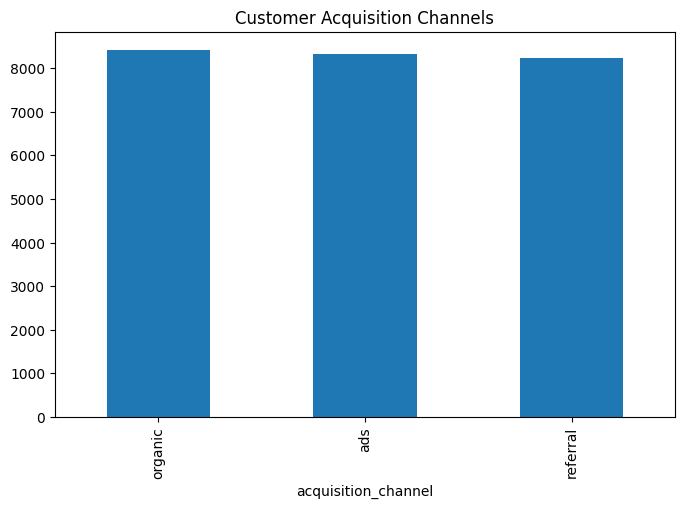

In [27]:
CUSTOMERS["acquisition_channel"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Acquisition Channels")
plt.show()

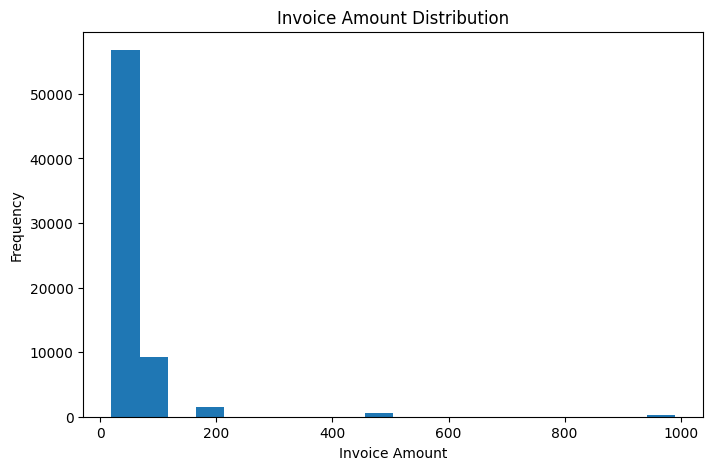

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    INVOICES["amount"],
    bins=20
)

plt.title("Invoice Amount Distribution")

plt.xlabel("Invoice Amount")

plt.ylabel("Frequency")

plt.show()

In [29]:
PAYMENTS["status"].value_counts()

status
successful    63614
failed         4797
Name: count, dtype: int64

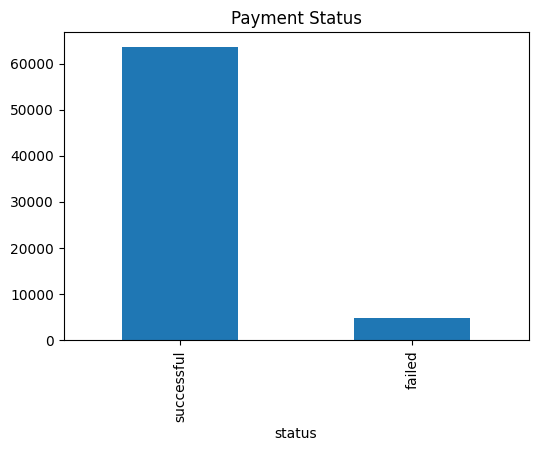

In [30]:
PAYMENTS["status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Payment Status")

plt.show()

In [31]:
SUBSCRIPTIONS["status"].value_counts()

status
active     15243
churned     9757
Name: count, dtype: int64

In [32]:
PLAN_ANALYSIS = SUBSCRIPTIONS.merge(
    SUBSCRIPTION_PLANS,
    on="plan_id"
)

PLAN_ANALYSIS["plan_name"].value_counts()

plan_name
Free       14187
Basic       6996
Pro         2574
Premium     1243
Name: count, dtype: int64

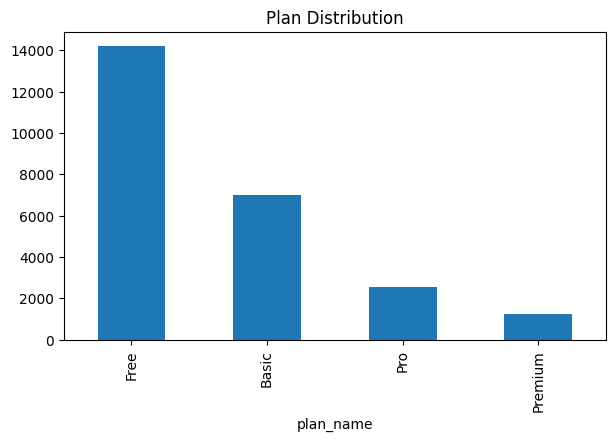

In [33]:
PLAN_ANALYSIS["plan_name"].value_counts().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Plan Distribution")

plt.show()

KEY FINDINGS

1. Data quality is acceptable with minimal missing values and duplicates.

2. Customer base is distributed across multiple countries and industries.

3. Paid invoices represent the majority of revenue activity.

4. Payment success rate remains strong.

5. Active subscriptions exceed churned subscriptions.

6. Premium and Pro plans contribute significantly to customer adoption.

7. Dataset is ready for revenue intelligence and churn analysis.